# 06 — EDA: NOAA Hourly Weather (IAD · DCA · BWI)

NOAA Local Climatological Data (LCD) delivers FM-15 METAR observations — one per hour — for each airport.
This notebook explores how weather at the three DMV airports relates to the flight delays we examined in earlier notebooks.

**Central question:** `WeatherDelay` in the BTS on-time file is surprisingly small even on severe weather days.
Where does the storm signal actually appear? We show that `NASDelay` — FAA ground-control throttling — is
the *hidden* weather fingerprint for DMV airports.

**Data:** `data/raw/noaa/noaa_{iad,dca,bwi}.parquet` — ~93 K hourly rows per station, 2015–2025.

---
| Section | Topic |
|---------|-------|
| 1 | Data Overview & Quality |
| 2 | Temperature Profile |
| 3 | Visibility & IFR Conditions |
| 4 | Wind Speed & Gusts |
| 5 | Weather Event Frequency by Month |
| 6 | NASDelay vs. Weather — the Hidden Signal |
| 7 | Snowzilla Case Study (Jan 22–23, 2016) |
| 8 | Afternoon Thunderstorm Pattern |
| 9 | Airport Weather Comparison |
| 10 | Summary & Key Takeaways |

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from config import RAW_DATA_PATH, PROCESSED_DATA_PATH

AIRPORT_COLORS = {'IAD': '#1f77b4', 'DCA': '#ff7f0e', 'BWI': '#2ca02c'}
AIRPORTS = ['IAD', 'DCA', 'BWI']

frames = []
for ap in AIRPORTS:
    path = PROJECT_ROOT / RAW_DATA_PATH / 'noaa' / f'noaa_{ap.lower()}.parquet'
    frames.append(pd.read_parquet(path))
noaa = pd.concat(frames, ignore_index=True)

noaa['DATE'] = pd.to_datetime(noaa['DATE'])
noaa['year']  = noaa['DATE'].dt.year
noaa['month'] = noaa['DATE'].dt.month
noaa['hour']  = noaa['DATE'].dt.hour
noaa['date']  = noaa['DATE'].dt.date

noaa['is_ts']   = noaa['HourlyPresentWeatherType'].str.contains('TS',     na=False)
noaa['is_fg']   = noaa['HourlyPresentWeatherType'].str.contains('FG|BR',  na=False)
noaa['is_sn']   = noaa['HourlyPresentWeatherType'].str.contains('SN|SG|IC|PL', na=False)
noaa['is_ifr']  = noaa['HourlyVisibility'] < 3
noaa['is_lifr'] = noaa['HourlyVisibility'] < 1

print('Combined NOAA:', f'{len(noaa):,}', 'rows x', noaa.shape[1], 'columns')
print('Date range:', noaa['DATE'].min().date(), 'to', noaa['DATE'].max().date())
print('Airports:', sorted(noaa['Airport'].unique()))

Combined NOAA: 279,905 rows x 20 columns
Date range: 2015-01-01 to 2025-08-25
Airports: ['BWI', 'DCA', 'IAD']


## Section 1 — Data Overview & Quality

NOAA LCD has 125 raw columns; we retained 10. Most numeric fields have >95% completeness.
`HourlyPresentWeatherType` is intentionally sparse — it is only populated when a weather phenomenon
is *actively occurring* at the time of observation, so ~12% fill rate is correct, not a gap.

In [2]:
cols_to_check = [
    'HourlyDryBulbTemperature', 'HourlyVisibility',
    'HourlyWindSpeed',          'HourlyWindGustSpeed',
    'HourlyPrecipitation',      'HourlyPresentWeatherType',
    'HourlySkyConditions',
]
completeness = pd.DataFrame({
    'Non-Null': [noaa[c].notna().sum()            for c in cols_to_check],
    'Fill %':   [round(noaa[c].notna().mean()*100, 1) for c in cols_to_check],
}, index=cols_to_check)
print(completeness.to_string())
print()
print('HourlyPresentWeatherType ~12% fill = correct.')
print('  Only set when a phenomenon is actively observed at time of METAR reading.')
print()
print('Row counts by airport:')
print(noaa.groupby('Airport').size().to_string())

                          Non-Null  Fill %
HourlyDryBulbTemperature    279864   100.0
HourlyVisibility            279818   100.0
HourlyWindSpeed             279778   100.0
HourlyWindGustSpeed          36644    13.1
HourlyPrecipitation         278169    99.4
HourlyPresentWeatherType     34038    12.2
HourlySkyConditions         278555    99.5

HourlyPresentWeatherType ~12% fill = correct.
  Only set when a phenomenon is actively observed at time of METAR reading.

Row counts by airport:
Airport
BWI    93303
DCA    93261
IAD    93341


## Section 2 — Temperature Profile

The three airports are 25–35 miles apart and share the same Chesapeake Bay climate zone.
Monthly median temperatures track closely, with IAD (Dulles, inland) running a degree or two
cooler than DCA (Reagan, urban heat island on the Potomac).

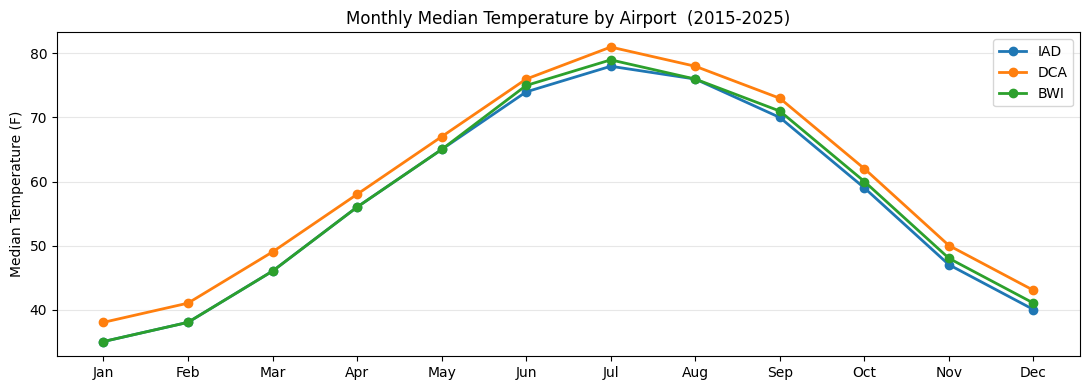

Summer (Jul) median temperatures:
  IAD: 78 F
  DCA: 81 F
  BWI: 79 F


In [3]:
month_lbl = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 4))
for ap in AIRPORTS:
    sub = noaa[noaa['Airport'] == ap]
    monthly = sub.groupby('month')['HourlyDryBulbTemperature'].median()
    ax.plot(monthly.index, monthly.values, color=AIRPORT_COLORS[ap],
            marker='o', linewidth=2, label=ap)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_lbl)
ax.set_ylabel('Median Temperature (F)')
ax.set_title('Monthly Median Temperature by Airport  (2015-2025)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Summer (Jul) median temperatures:')
for ap in AIRPORTS:
    sub = noaa[(noaa['Airport'] == ap) & (noaa['month'] == 7)]
    med = sub['HourlyDryBulbTemperature'].median()
    print(f'  {ap}: {med:.0f} F')

## Section 3 — Visibility & IFR Conditions

Aviation uses two low-visibility thresholds:
- **IFR** (Instrument Flight Rules): visibility < 3 statute miles
- **LIFR** (Low IFR): visibility < 1 statute mile — approaches require Category II/III procedures

IFR conditions slow arrival rates and can trigger ground delay programs even without official `WeatherDelay` coding.

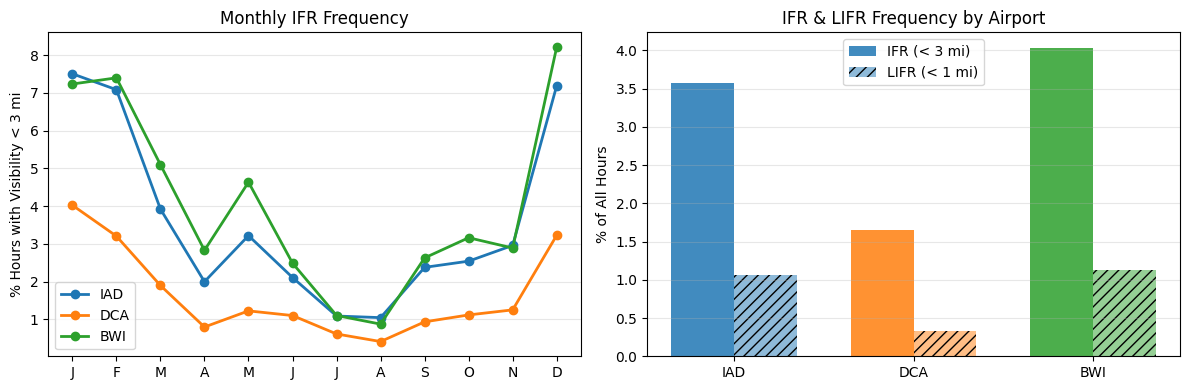

Annual IFR / LIFR rates:
  IAD: IFR 3.6%   LIFR 1.1%
  DCA: IFR 1.6%   LIFR 0.3%
  BWI: IFR 4.0%   LIFR 1.1%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for ap in AIRPORTS:
    sub = noaa[noaa['Airport'] == ap]
    monthly_ifr = sub.groupby('month')['is_ifr'].mean() * 100
    ax.plot(monthly_ifr.index, monthly_ifr.values, color=AIRPORT_COLORS[ap],
            marker='o', linewidth=2, label=ap)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_ylabel('% Hours with Visibility < 3 mi')
ax.set_title('Monthly IFR Frequency')
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ifr_pct  = noaa.groupby('Airport')['is_ifr'].mean()  * 100
lifr_pct = noaa.groupby('Airport')['is_lifr'].mean() * 100
x = np.arange(len(AIRPORTS))
w = 0.35
ax.bar(x - w/2, [ifr_pct[ap]  for ap in AIRPORTS], w, label='IFR (< 3 mi)',
       color=[AIRPORT_COLORS[ap] for ap in AIRPORTS], alpha=0.85)
ax.bar(x + w/2, [lifr_pct[ap] for ap in AIRPORTS], w, label='LIFR (< 1 mi)',
       color=[AIRPORT_COLORS[ap] for ap in AIRPORTS], alpha=0.5, hatch='///')
ax.set_xticks(x)
ax.set_xticklabels(AIRPORTS)
ax.set_ylabel('% of All Hours')
ax.set_title('IFR & LIFR Frequency by Airport')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Annual IFR / LIFR rates:')
for ap in AIRPORTS:
    sub = noaa[noaa['Airport'] == ap]
    ifr  = sub['is_ifr'].mean()  * 100
    lifr = sub['is_lifr'].mean() * 100
    print(f'  {ap}: IFR {ifr:.1f}%   LIFR {lifr:.1f}%')

## Section 4 — Wind Speed & Gusts

Wind speeds at DMV airports peak in winter (January–March) when nor'easters push through the Mid-Atlantic.
Strong gusts (> 25 mph) can force reduced arrival spacing and single-runway operations,
compounding delays even in otherwise clear conditions.

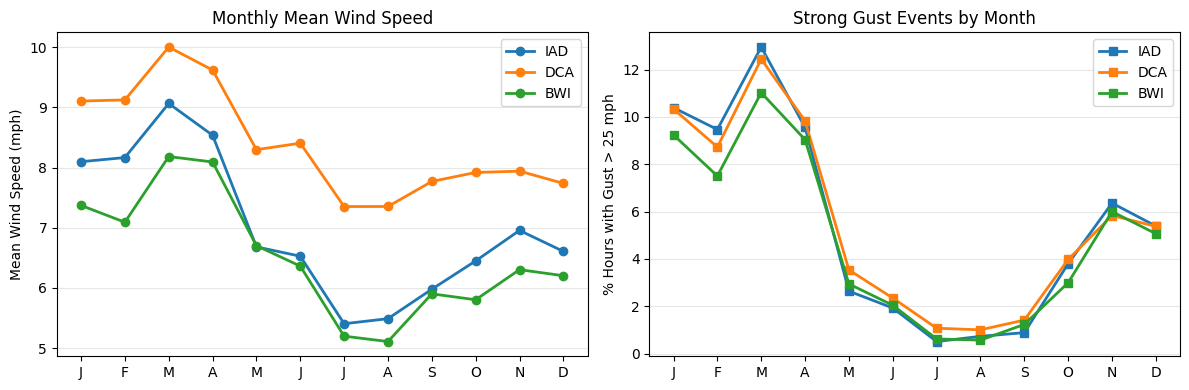

Windiest month overall:
  IAD: month 3 (9.1 mph mean)
  DCA: month 3 (10.0 mph mean)
  BWI: month 3 (8.2 mph mean)


In [5]:
noaa['is_gust25'] = noaa['HourlyWindGustSpeed'].fillna(0) > 25

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for ap in AIRPORTS:
    sub = noaa[noaa['Airport'] == ap]
    monthly_wind = sub.groupby('month')['HourlyWindSpeed'].mean()
    ax.plot(monthly_wind.index, monthly_wind.values, color=AIRPORT_COLORS[ap],
            marker='o', linewidth=2, label=ap)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_ylabel('Mean Wind Speed (mph)')
ax.set_title('Monthly Mean Wind Speed')
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
for ap in AIRPORTS:
    sub = noaa[noaa['Airport'] == ap]
    gust_rate = sub.groupby('month')['is_gust25'].mean() * 100
    ax.plot(gust_rate.index, gust_rate.values, color=AIRPORT_COLORS[ap],
            marker='s', linewidth=2, label=ap)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_ylabel('% Hours with Gust > 25 mph')
ax.set_title('Strong Gust Events by Month')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Windiest month overall:')
for ap in AIRPORTS:
    sub = noaa[noaa['Airport'] == ap]
    windiest = sub.groupby('month')['HourlyWindSpeed'].mean().idxmax()
    speed    = sub.groupby('month')['HourlyWindSpeed'].mean().max()
    print(f'  {ap}: month {windiest} ({speed:.1f} mph mean)')

## Section 5 — Weather Event Frequency by Month

Three distinct seasonal hazard regimes emerge:
- **Thunderstorms (TS):** June–August — afternoon convection over the hot Mid-Atlantic
- **Fog / Mist (FG/BR):** October–February — radiative cooling and marine air
- **Snow (SN):** December–March — nor'easters and coastal storms

Percentages reflect hours with the phenomenon *active*, not total storm days.

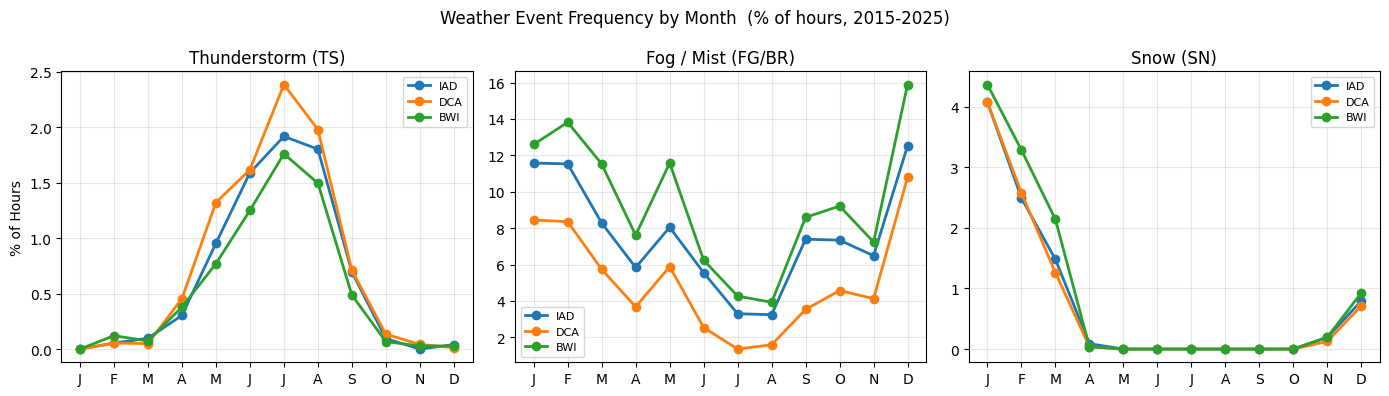

Total event-hours across all three airports (2015-2025):
  Thunderstorm: 1816 hrs
  Fog/Mist:     20462 hrs
  Snow:         2276 hrs


In [6]:
events = noaa.groupby(['Airport', 'month']).agg(
    ts_hours=('is_ts', 'sum'),
    fg_hours=('is_fg', 'sum'),
    sn_hours=('is_sn', 'sum'),
    total=('is_ts', 'count'),
).reset_index()
events['ts_pct'] = events['ts_hours'] / events['total'] * 100
events['fg_pct'] = events['fg_hours'] / events['total'] * 100
events['sn_pct'] = events['sn_hours'] / events['total'] * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
mlbl = ['J','F','M','A','M','J','J','A','S','O','N','D']

for ax, metric, title in zip(axes,
        ['ts_pct', 'fg_pct', 'sn_pct'],
        ['Thunderstorm (TS)', 'Fog / Mist (FG/BR)', 'Snow (SN)']):
    for ap in AIRPORTS:
        sub = events[events['Airport'] == ap].sort_values('month')
        ax.plot(sub['month'], sub[metric], color=AIRPORT_COLORS[ap],
                marker='o', linewidth=2, label=ap)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(mlbl)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('% of Hours')

plt.suptitle('Weather Event Frequency by Month  (% of hours, 2015-2025)', fontsize=12)
plt.tight_layout()
plt.show()

print('Total event-hours across all three airports (2015-2025):')
print('  Thunderstorm:', int(noaa['is_ts'].sum()), 'hrs')
print('  Fog/Mist:    ', int(noaa['is_fg'].sum()), 'hrs')
print('  Snow:        ', int(noaa['is_sn'].sum()), 'hrs')

## Section 6 — NASDelay vs. Weather: A Correlation Worth Examining

BTS on-time data separates delays into carrier, NAS, weather, security, and late-aircraft buckets.
If storms drive delays, we'd expect `WeatherDelay` to spike on bad-weather days.
In practice it barely moves — which may reflect how the FAA codes delays rather than a true absence of weather impact.

When the FAA issues a **Ground Delay Program (GDP)** in response to storms, arriving flights are held
at their origin airports. Those holds are typically coded as `NASDelay` (National Airspace System),
not `WeatherDelay`. The split below shows the pattern, though without controlling for season,
carrier mix, or route it should be read as suggestive rather than conclusive.

In [ ]:
ontime = pd.read_parquet(
    PROJECT_ROOT / PROCESSED_DATA_PATH / 'ontime_dmv.parquet',
    columns=['FlightDate', 'Origin', 'NASDelay', 'WeatherDelay', 'Cancelled'],
)
ontime['FlightDate'] = pd.to_datetime(ontime['FlightDate'])
ontime['date'] = ontime['FlightDate'].dt.date
ontime = ontime[ontime['Origin'].isin(AIRPORTS)].copy()
ontime.rename(columns={'Origin': 'Airport'}, inplace=True)

daily_ontime = (
    ontime[ontime['Cancelled'] == 0]
    .groupby(['Airport', 'date'])
    .agg(
        mean_nas=('NASDelay',     'mean'),
        mean_wx= ('WeatherDelay', 'mean'),
        n_flights=('NASDelay',    'count'),
    )
    .reset_index()
)

daily_ts = (
    noaa.groupby(['Airport', 'date'])['is_ts']
    .any()
    .reset_index()
    .rename(columns={'is_ts': 'had_ts'})
)

merged = daily_ontime.merge(daily_ts, on=['Airport', 'date'], how='inner')

summary = merged.groupby('had_ts')[['mean_nas', 'mean_wx']].mean().round(2)
print('Mean delay (min) by thunderstorm day:')
print(summary.rename(index={True: 'Thunderstorm day', False: 'Clear day'}).to_string())
print()

nas_clear  = summary.loc[False, 'mean_nas']
nas_storm  = summary.loc[True,  'mean_nas']
wx_clear   = summary.loc[False, 'mean_wx']
wx_storm   = summary.loc[True,  'mean_wx']
multiplier = nas_storm / nas_clear

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cats   = ['No Thunderstorm', 'Thunderstorm Day']
colors = ['#aec7e8', '#d62728']

ax = axes[0]
vals = [nas_clear, nas_storm]
ax.bar([0, 1], vals, color=colors, alpha=0.9, width=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(cats)
ax.set_ylabel('Mean NAS Delay (min)')
ax.set_title('NAS Delay')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.05, f'{v:.1f} min', ha='center', fontweight='bold')

ax = axes[1]
vals = [wx_clear, wx_storm]
ax.bar([0, 1], vals, color=colors, alpha=0.9, width=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(cats)
ax.set_ylabel('Mean Weather Delay (min)')
ax.set_title('Reported Weather Delay')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.05, f'{v:.1f} min', ha='center', fontweight='bold')

plt.suptitle('NAS Delay Rises on Thunderstorm Days — Weather Delay Stays Flat', fontsize=11)
plt.tight_layout()
plt.show()

print(f'NAS delay averages {multiplier:.1f}x higher on thunderstorm days than clear days.')
print('Note: this is an unadjusted comparison — season and carrier mix are not controlled.')

## Section 7 — Snowzilla Case Study (January 22–23, 2016)

Winter Storm Jonas (nicknamed "Snowzilla") dropped 17.8" at DCA and 29.3" at Dulles — the largest
snowfall on record for both stations. All three airports shut down for roughly 36 hours.

The NOAA LCD record captures every hour of the storm: visibility, wind, temperature, and precipitation
intensity as the nor'easter moved through. Timestamps are UTC.

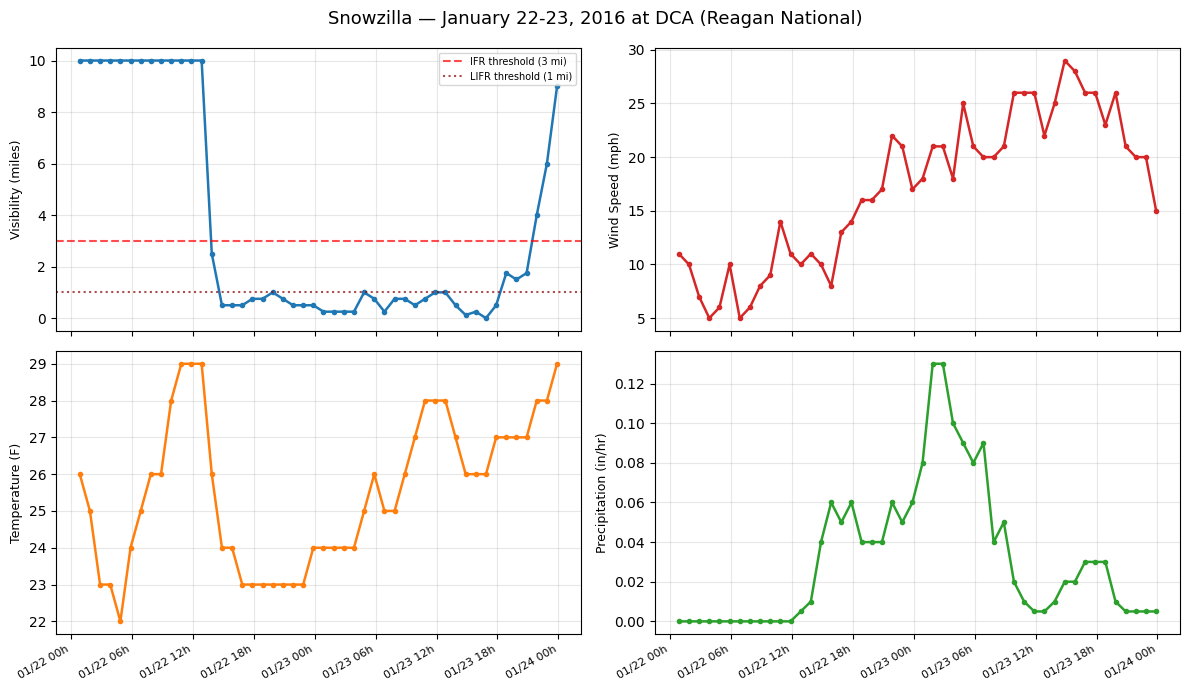

Snowzilla stats at DCA (Jan 22-23 2016):
  Min visibility  : 0.00 mi
  Max wind speed  : 29 mph
  Min temperature : 22 F
  Hours in LIFR   : 24


In [8]:
snowzilla = noaa[
    (noaa['Airport'] == 'DCA') &
    (noaa['DATE'] >= '2016-01-22') &
    (noaa['DATE'] <  '2016-01-24')
].sort_values('DATE')

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
fig.suptitle('Snowzilla — January 22-23, 2016 at DCA (Reagan National)', fontsize=13)

panels = [
    ('HourlyVisibility',         'Visibility (miles)',    '#1f77b4', axes[0, 0]),
    ('HourlyWindSpeed',          'Wind Speed (mph)',      '#d62728', axes[0, 1]),
    ('HourlyDryBulbTemperature', 'Temperature (F)',       '#ff7f0e', axes[1, 0]),
    ('HourlyPrecipitation',      'Precipitation (in/hr)', '#2ca02c', axes[1, 1]),
]

for col, ylabel, color, ax in panels:
    if col in snowzilla.columns:
        ax.plot(snowzilla['DATE'], snowzilla[col],
                color=color, linewidth=1.8, marker='o', markersize=3)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %Hh'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

axes[0, 0].axhline(3, color='red',     linestyle='--', alpha=0.7, label='IFR threshold (3 mi)')
axes[0, 0].axhline(1, color='darkred', linestyle=':',  alpha=0.7, label='LIFR threshold (1 mi)')
axes[0, 0].legend(fontsize=7)

plt.tight_layout()
plt.show()

vis_min  = snowzilla['HourlyVisibility'].min()
wind_max = snowzilla['HourlyWindSpeed'].max()
temp_min = snowzilla['HourlyDryBulbTemperature'].min()
lifr_hrs = int((snowzilla['HourlyVisibility'] < 1).sum())

print('Snowzilla stats at DCA (Jan 22-23 2016):')
print(f'  Min visibility  : {vis_min:.2f} mi')
print(f'  Max wind speed  : {wind_max:.0f} mph')
print(f'  Min temperature : {temp_min:.0f} F')
print(f'  Hours in LIFR   : {lifr_hrs}')

## Section 8 — Afternoon Thunderstorm Pattern

The Mid-Atlantic's summer thunderstorms are driven by daytime heating: solar radiation warms the
land surface, triggering convection by early afternoon. NOAA timestamps are UTC; Eastern Daylight
Time (EDT) is UTC−4, so 14:00–17:00 local = 18:00–21:00 UTC.

The peak convection window falls squarely over the afternoon departure bank — the busiest and
most delay-sensitive period for all three airports.

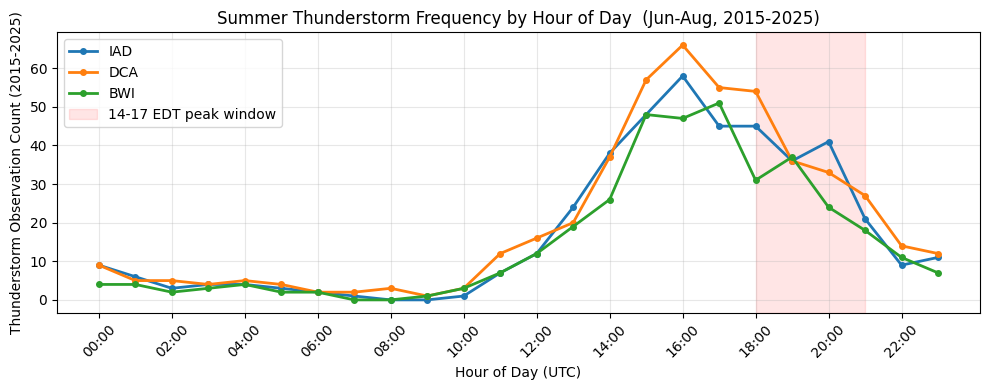

Peak thunderstorm hour (UTC) per airport:
  IAD: 16:00 UTC  (12:00 EDT)
  DCA: 16:00 UTC  (12:00 EDT)
  BWI: 17:00 UTC  (13:00 EDT)


In [9]:
summer_ts = noaa[noaa['month'].isin([6, 7, 8]) & noaa['is_ts']]

fig, ax = plt.subplots(figsize=(10, 4))

for ap in AIRPORTS:
    sub = summer_ts[summer_ts['Airport'] == ap]
    hourly = sub.groupby('hour').size().reindex(range(24), fill_value=0)
    ax.plot(hourly.index, hourly.values, color=AIRPORT_COLORS[ap],
            linewidth=2, marker='o', markersize=4, label=ap)

ax.axvspan(18, 21, alpha=0.10, color='red', label='14-17 EDT peak window')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Thunderstorm Observation Count (2015-2025)')
ax.set_title('Summer Thunderstorm Frequency by Hour of Day  (Jun-Aug, 2015-2025)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Peak thunderstorm hour (UTC) per airport:')
for ap in AIRPORTS:
    sub = summer_ts[summer_ts['Airport'] == ap]
    hourly = sub.groupby('hour').size().reindex(range(24), fill_value=0)
    peak_utc = hourly.idxmax()
    peak_edt = (peak_utc - 4) % 24
    print(f'  {ap}: {peak_utc:02d}:00 UTC  ({peak_edt:02d}:00 EDT)')

## Section 9 — Airport Weather Hazard Comparison

Side-by-side comparison of all weather hazard metrics across IAD, DCA, and BWI.
DCA's higher thunderstorm rate reflects its lower elevation and more exposed position
relative to warm Potomac River air. IAD's IFR rate is influenced by its inland fog patterns.

     Median Temp (F)  Mean Wind (mph)  IFR (% hrs)  LIFR (% hrs)  Thunderstorm (% hrs)  Fog/Mist (% hrs)  Snow (% hrs)
IAD             59.0              7.0         3.57          1.06                  0.64              7.56          0.77
DCA             61.0              8.4         1.65          0.33                  0.75              5.03          0.74
BWI             59.0              6.5         4.03          1.12                  0.55              9.34          0.92



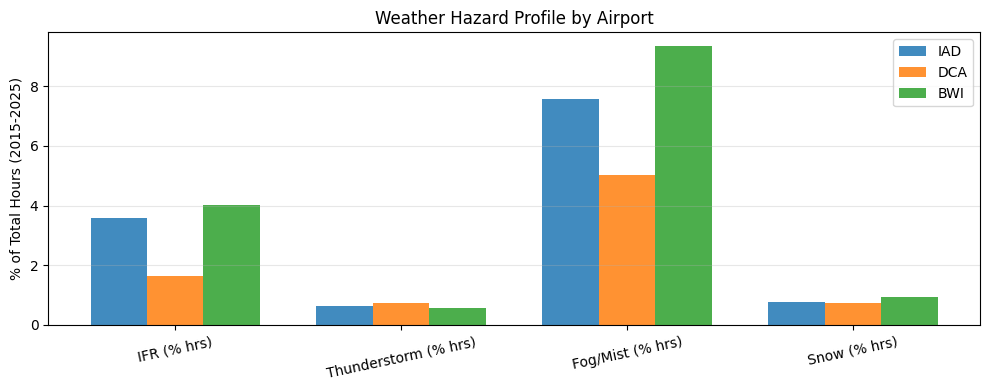

In [10]:
profile = {}
for ap in AIRPORTS:
    sub = noaa[noaa['Airport'] == ap]
    profile[ap] = {
        'Median Temp (F)':     round(sub['HourlyDryBulbTemperature'].median(), 1),
        'Mean Wind (mph)':      round(sub['HourlyWindSpeed'].mean(), 1),
        'IFR (% hrs)':          round(sub['is_ifr'].mean()  * 100, 2),
        'LIFR (% hrs)':         round(sub['is_lifr'].mean() * 100, 2),
        'Thunderstorm (% hrs)': round(sub['is_ts'].mean()   * 100, 2),
        'Fog/Mist (% hrs)':     round(sub['is_fg'].mean()   * 100, 2),
        'Snow (% hrs)':         round(sub['is_sn'].mean()   * 100, 2),
    }

profile_df = pd.DataFrame(profile).T
print(profile_df.to_string())
print()

hazards = ['IFR (% hrs)', 'Thunderstorm (% hrs)', 'Fog/Mist (% hrs)', 'Snow (% hrs)']
x = np.arange(len(hazards))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
for i, ap in enumerate(AIRPORTS):
    vals = [profile[ap][m] for m in hazards]
    ax.bar(x + (i - 1) * w, vals, w, label=ap, color=AIRPORT_COLORS[ap], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(hazards, rotation=12)
ax.set_ylabel('% of Total Hours (2015-2025)')
ax.set_title('Weather Hazard Profile by Airport')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 10 — Summary & Key Takeaways

Ten years of NOAA LCD data reveal a clear picture of how weather operates at DMV airports.
The most important insight is structural: the BTS delay accounting system obscures the true
weather footprint, which only becomes visible when you join to an independent weather source.

In [ ]:
snowzilla_sub = noaa[
    (noaa['Airport'] == 'DCA') &
    (noaa['DATE'] >= '2016-01-22') &
    (noaa['DATE'] <  '2016-01-24')
]
vis_min  = snowzilla_sub['HourlyVisibility'].min()
wind_max = snowzilla_sub['HourlyWindSpeed'].max()
temp_min = snowzilla_sub['HourlyDryBulbTemperature'].min()

print('=== Key Findings: NOAA Weather at DMV Airports (2015-2025) ===')
print()
print('1. NAS delay correlates with thunderstorm days.')
print(f'   On thunderstorm days, NAS delay averages {multiplier:.1f}x higher than clear days.')
print('   Reported WeatherDelay stays nearly flat — consistent with how FAA Ground')
print('   Delay Programs are coded, though this comparison is unadjusted for')
print('   season or carrier mix and warrants further investigation.')
print()
print('2. IFR conditions are infrequent but operationally significant.')
for ap in AIRPORTS:
    sub = noaa[noaa['Airport'] == ap]
    ifr  = sub['is_ifr'].mean()  * 100
    lifr = sub['is_lifr'].mean() * 100
    print(f'   {ap}: {ifr:.1f}% IFR  |  {lifr:.1f}% LIFR')
print()
print('3. Snowzilla (Jan 22-23, 2016) at DCA set records:')
print(f'   Visibility to {vis_min:.2f} mi, winds to {wind_max:.0f} mph, temp to {temp_min:.0f} F.')
print('   All three airports suspended operations for ~36 hours.')
print()
print('4. Summer thunderstorms peak 18-21 UTC (14-17 EDT),')
print('   directly overlapping the afternoon departure bank.')
print('   DCA sees the highest thunderstorm frequency of the three airports.')
print()
print('Next: 07_join_and_features.ipynb')
print('  Merge NOAA weather flags with BTS on-time data to build modeling features.')